In [30]:
import numpy as np
import matplotlib.pyplot as plt
from plant.parameters import params
import sys, os
sys.path.append(os.path.abspath('..'))
from plant.battery import Uoc, coef_cubic,battery_step, thermal_model
from plant.powertrain import powertrain
from scipy.interpolate import RegularGridInterpolator

In [31]:
#Define Parameters
dt = 0.1

Q_bat = params['E_pack_capacity']/params['V_oc_nom'] 

# Limits on Batt Power, Eng Power, SOC
P_MGU_K_min = params['P_MGU_min']   # -200[kW]
P_MGU_K_max = params['P_MGU_max']   # 350[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]

E_ES2K_max = params['E_deploy_max'] # 9[MJ]

SoC_min = params['SoC_min']     # 0.2[-]
SoC_max = params['SoC_max']     # 0.9[-]

eta_ICE = params['eta_ICE']     # 0.489
P_ICE0 = params['P_ICE0']       # 15[kW]
LHV = params['LHV']

#data = np.load('/app/data/multi_lap_Canada/Canada_5laps.npy')
data = np.load('/app/data/multi_lap_Canada/Canada_5laps.npy')

t = data[0,:]
N_lap = data[1,:]
v = data[2,:]
a = data[3,:]

power_data = np.load('data/multi_lap_Canada/power_domand_multilap.npy')

Pgb = power_data[1,:]


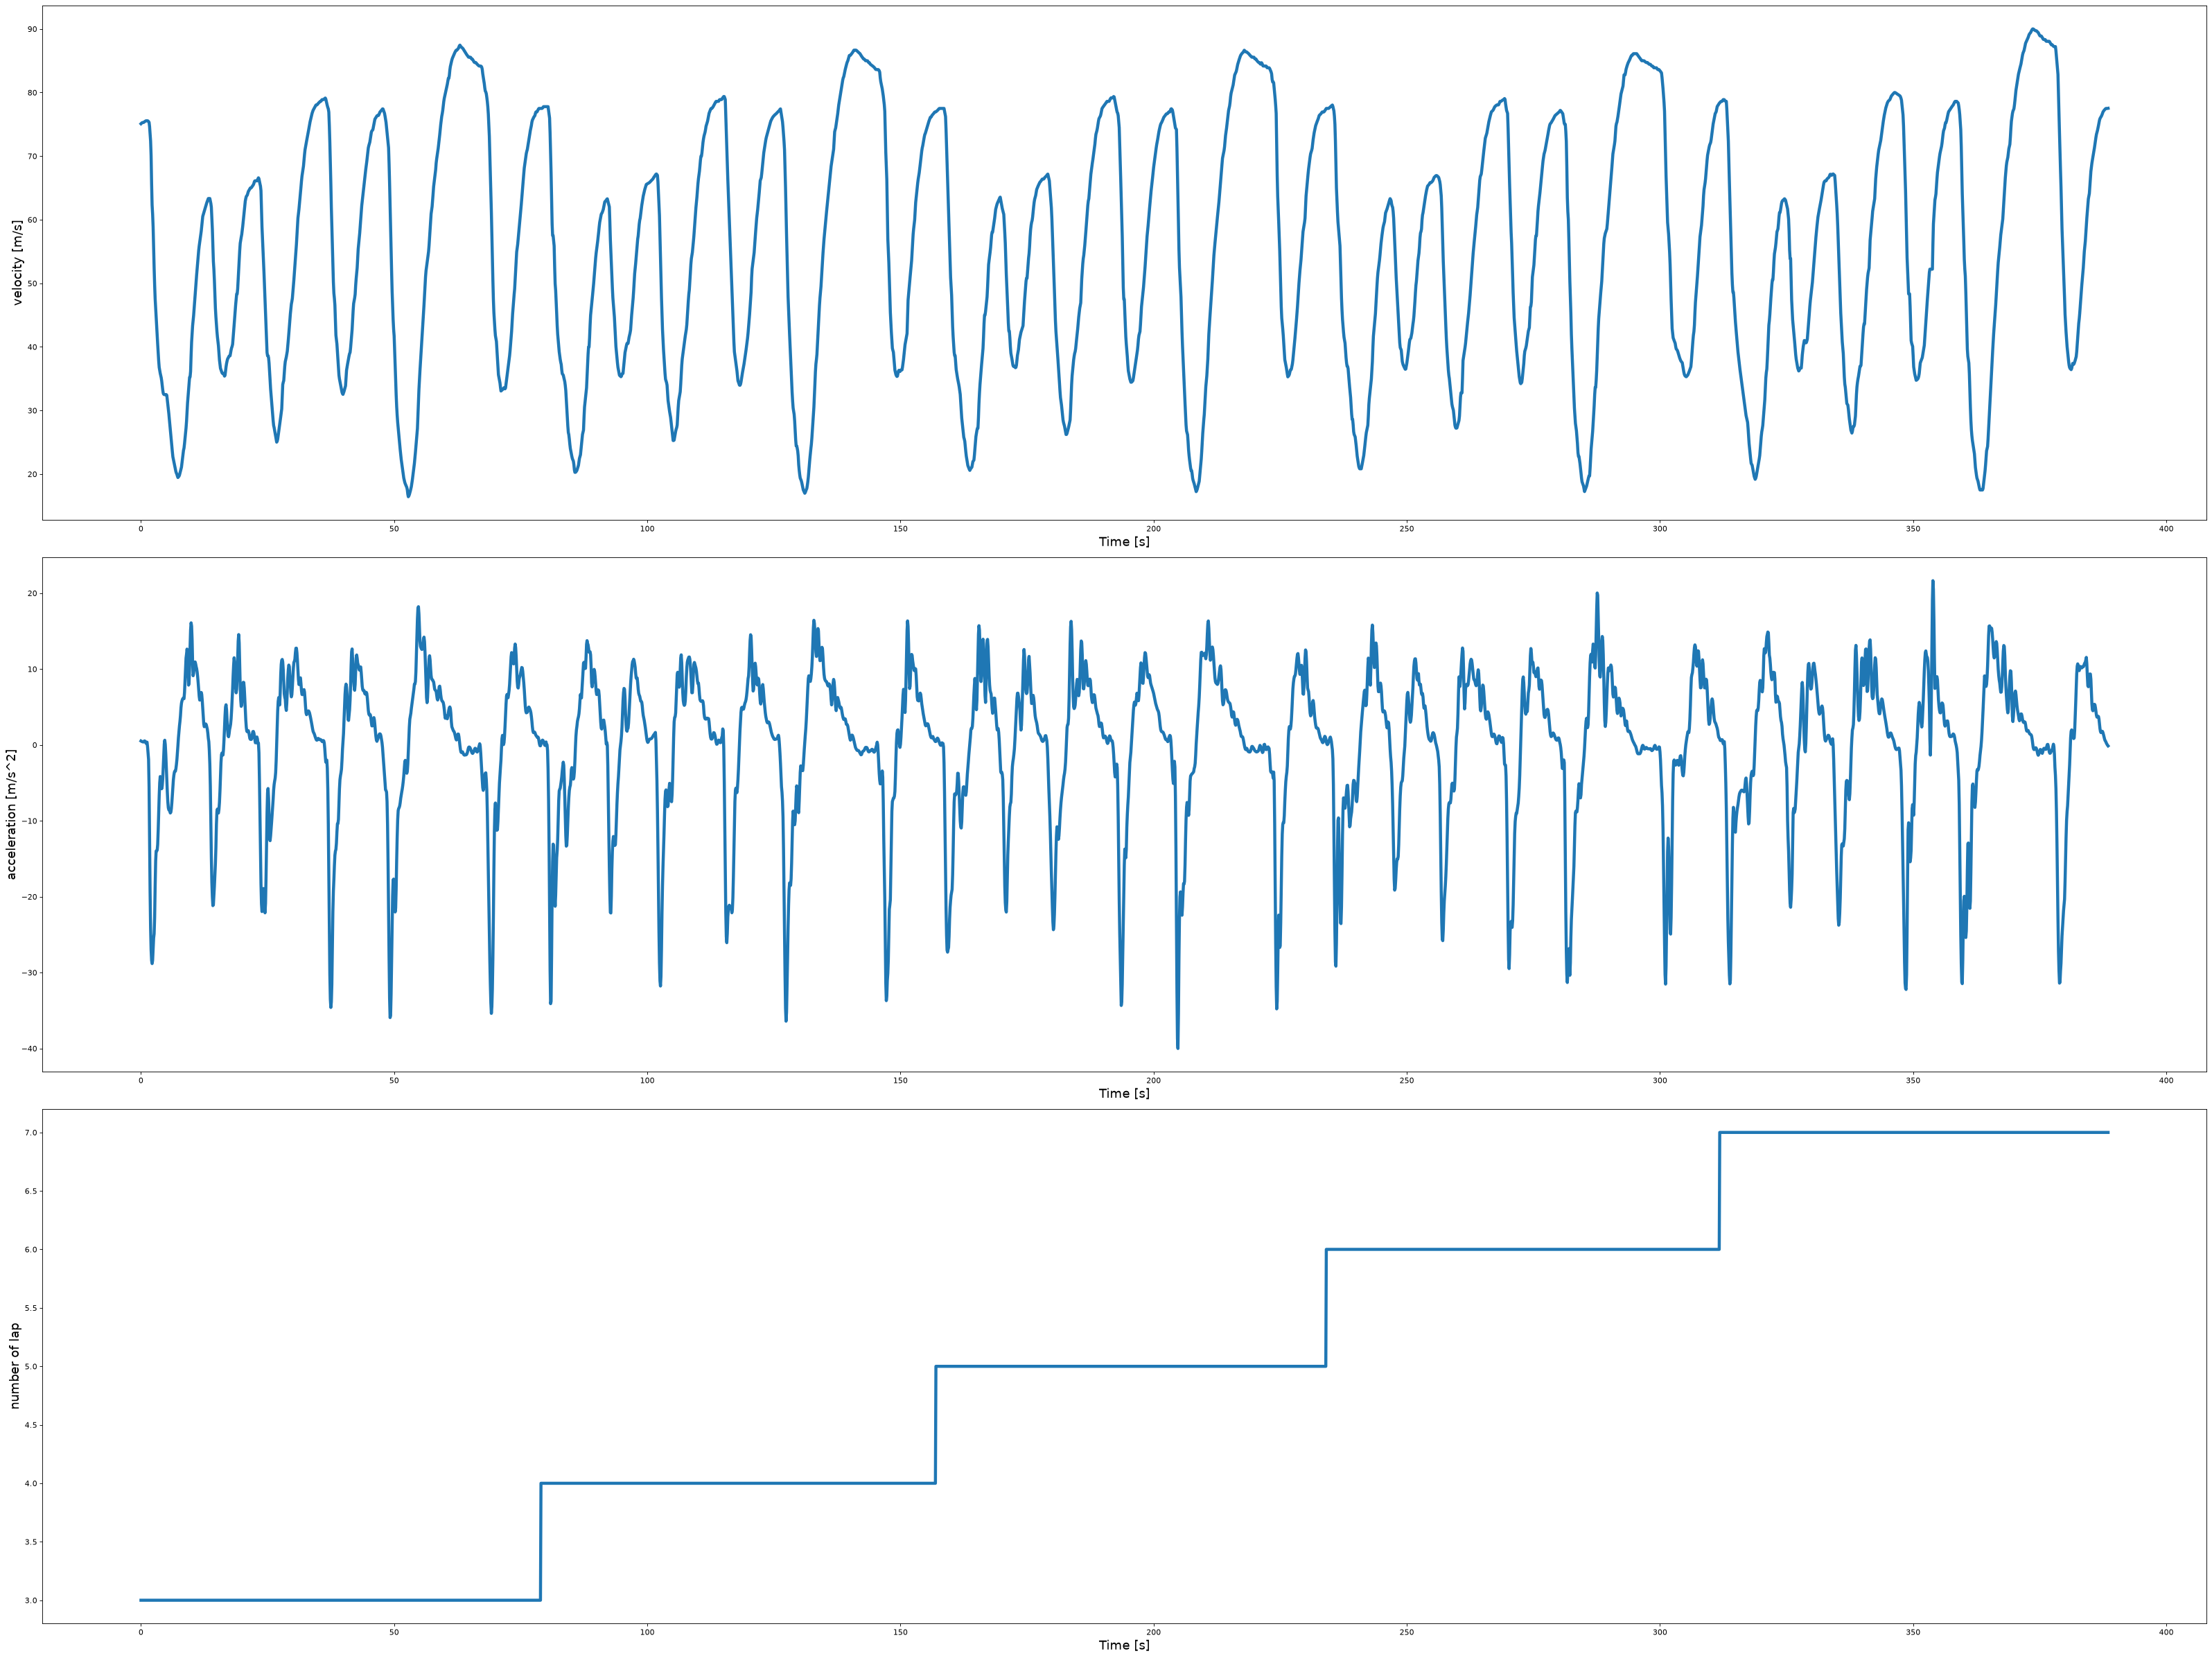

In [32]:
plt.figure(num=1, figsize=(40, 30), dpi=80, facecolor='w', edgecolor='k')

plt.subplot(3,1,1)
plt.plot(t,v, linewidth=4)
plt.xlabel('Time [s]', fontsize=16)
plt.ylabel('velocity [m/s]', fontsize=16)

plt.subplot(3,1,2)
plt.plot(t,a, linewidth=4)
plt.xlabel('Time [s]', fontsize=16)
plt.ylabel('acceleration [m/s^2]', fontsize=16)

plt.subplot(3,1,3)
plt.plot(t,N_lap, linewidth=4)
plt.xlabel('Time [s]', fontsize=16)
plt.ylabel('number of lap', fontsize=16)
plt.tight_layout()
plt.show()

In [33]:
SoC_grid = np.linspace(SoC_min,SoC_max, 50)
E_ES2K_grid = np.linspace(0,E_ES2K_max, 50)

#grid size
ns = len(SoC_grid)
ne = len(E_ES2K_grid)

#planning horizon (time steps)
N = len(t)
# Preallocate Value Function (rows index state, columns index time)
V = np.inf*np.ones((ns,ne,N+1))
#preollacate control (row index states, and columns index time)
u_star = np.zeros_like(V)
nu = 200

# Boundary Condition of Value Function (Principle of Optimality)
V[:,:,N] = 0

SoC_mesh,E_ES2K_mesh  = np.meshgrid(SoC_grid,E_ES2K_grid, indexing='ij')
SoC_max_term = (SoC_max-SoC_mesh)*Q_bat*Uoc(SoC_mesh,coef_cubic)/-dt
SoC_min_term = (SoC_min-SoC_mesh)*Q_bat*Uoc(SoC_mesh,coef_cubic)/-dt

E_ES2K_term = (E_ES2K_max-E_ES2K_mesh)/dt

In [42]:
for k in range(N-1, -1, -1):
    interp_Vnext = RegularGridInterpolator((SoC_grid, E_ES2K_grid), V[:,:,k+1], bounds_error=False, fill_value=None)
    if Pgb[k]>=0:
        lb = np.maximum(SoC_max_term, Pgb[k] - P_eng_max)
        ub = np.minimum(SoC_min_term,Pgb[k])
        ub = np.minimum(ub, np.minimum(E_ES2K_term,P_MGU_K_max))

    else:
        lb = np.maximum(Pgb[k],np.maximum(SoC_max_term,P_MGU_K_min))
        ub = np.minimum(0,SoC_min_term)

    P_mgu_k_mesh = np.linspace(lb,ub,nu, axis=-1)

    if Pgb[k]>=0:
        P_eng = Pgb[k]-P_mgu_k_mesh
    else:
        P_eng = np.zeros_like(P_mgu_k_mesh)

    mdot = (P_eng+P_ICE0)/(eta_ICE*LHV)
    mdot = np.clip(mdot, 0,params['m_dot_max']/3600)

    # cost-per-time
    g_k = mdot*dt

    #compute the dynamics of the states
    Soc_next = SoC_mesh[:,:,np.newaxis] - dt*P_mgu_k_mesh/(Q_bat*Uoc(SoC_mesh[:,:,np.newaxis],coef_cubic))
    if k< N-1 and N_lap[k-1] < N_lap[k]:
        E_ES2K_next = np.zeros_like(Soc_next)
    else:
        E_ES2K_next = E_ES2K_mesh[:,:,np.newaxis] + np.maximum(0, P_mgu_k_mesh)*dt

    point = np.stack([Soc_next.ravel(), E_ES2K_next.ravel()], axis=-1)
    V_next = interp_Vnext(point).reshape(ns,ne,nu)
    
    V[:,:,k] = np.min(g_k+V_next, axis =-1) 
    ind = np.argmin(g_k+V_next, axis = -1)
    u_star[:,:,k] = np.take_along_axis(P_mgu_k_mesh, ind[:,:,np.newaxis], axis=-1).squeeze(axis=-1)



In [43]:
def foward_step(SoC_0, E_ES2K_0):
    SoC_sim = np.zeros(N)
    E_ES2K_sim = np.zeros(N)
    E_K2ES_sim = np.zeros(N)
    J_sim = np.zeros(N)
    P_eng_sim= np.zeros(N)
    P_mgu_k_sim =np.zeros(N)
    P_mech_MGU_K_real =np.zeros(N)
    m_dot_sim= np.zeros(N)
    Tbat_sim = np.zeros(N)

    SoC_sim[0] = SoC_0
    E_ES2K_sim[0] = E_ES2K_0
    E_K2ES_sim[0] = 0
    Tbat_sim[0] = params['T_bat_init']

    for i in range(0,N):
        interp_u = RegularGridInterpolator((SoC_grid,E_ES2K_grid),u_star[:,:,i], bounds_error=False, fill_value=None)
        point = np.array([[SoC_sim[i], E_ES2K_sim[i]]])
        P_mgu_k_sim[k] = interp_u(point)[0]

        P_eng_sim[k], P_elect_MGU_K,P_mech_MGU_K_real[k],_, E_ES2K_sim[k+1],E_ES2K_sim[k+1],m_dot_sim[k] = powertrain(Pgb[k],P_mgu_k_sim[k],E_ES2K_sim[k],E_K2ES_sim[k],params,dt, control_mode='P2')
        SoC_sim[k+1], _,I2 = battery_step(SoC_sim[k],P_elect_MGU_K, coef_cubic, Tbat_sim[k],params,dt)
        Tbat_sim[k+1] = thermal_model(I2, Tbat_sim[k], params, dt)

        J_sim[k] = m_dot_sim[k]*dt

    return P_eng_sim,P_mech_MGU_K_real, E_ES2K_sim, E_ES2K_sim, SoC_sim, Tbat_sim,J_sim


P_eng_sim90,P_mech_MGU_K_real90, E_ES2K_sim90, E_ES2K_sim90, SoC_sim90, Tbat_sim90,J_sim90 = foward_step(SoC_0=0.9, E_ES2K_0=0.0)    
    

/tmp/ipykernel_39149/1636091579.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=1, fontsize=12)


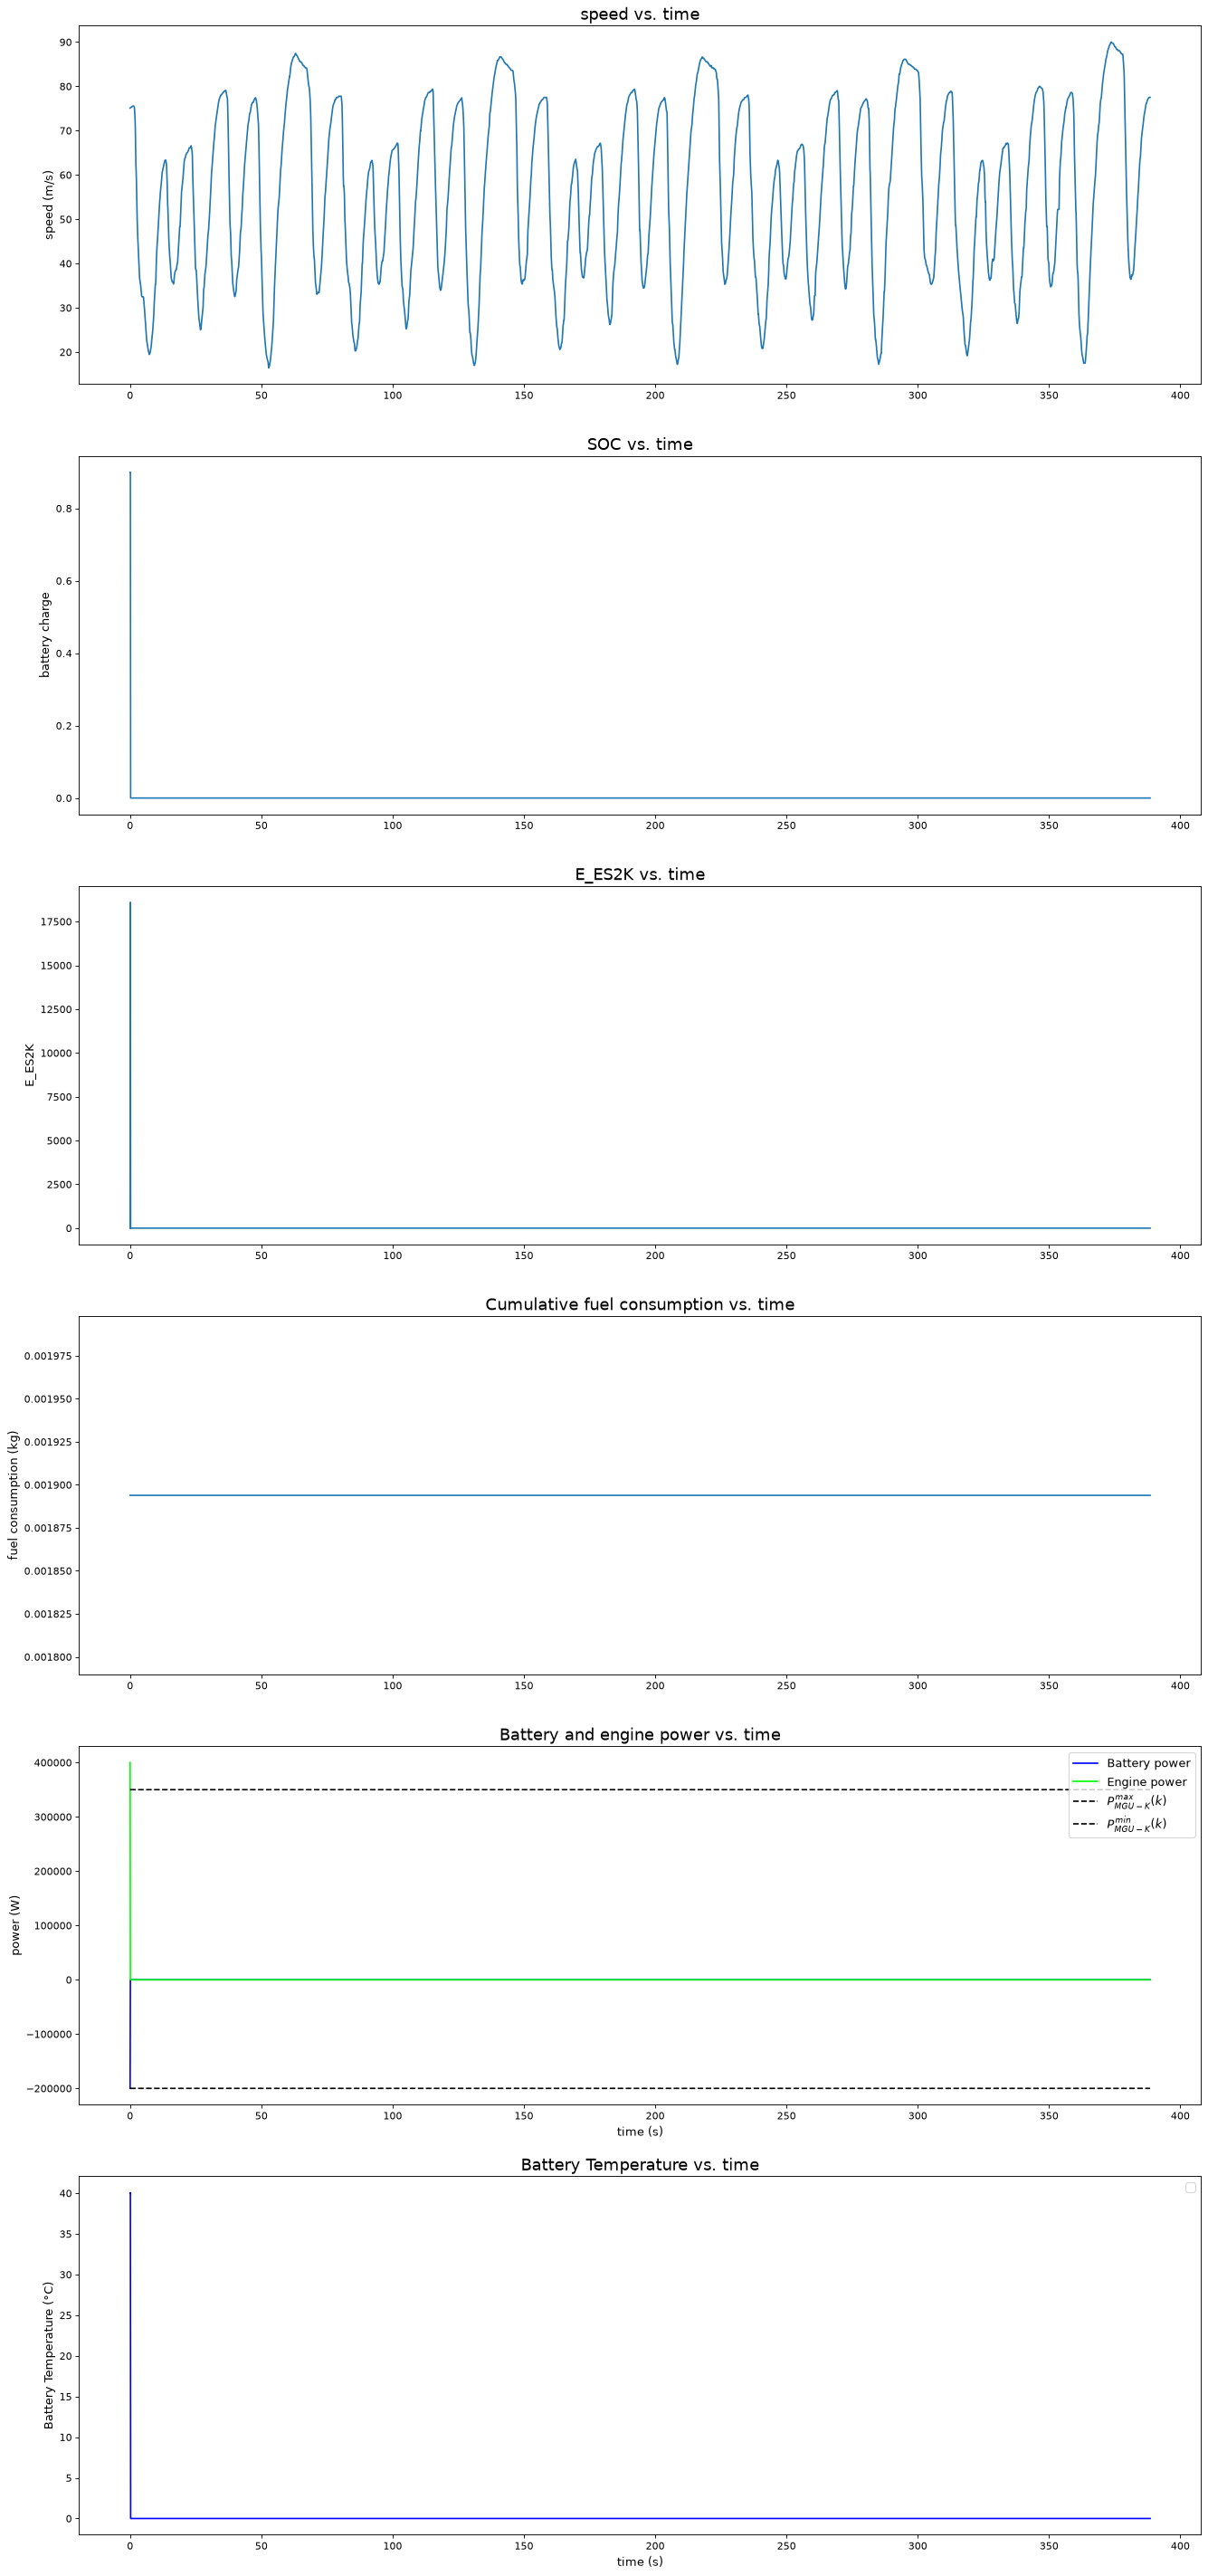

In [44]:
## Plot Simulation Results
plt.figure(num=6, figsize=(20, 45), dpi=80, facecolor='w', edgecolor='k')


plt.subplot(6,1,1)

plt.plot(t, v)
plt.ylabel('speed (m/s)', fontsize=12)
plt.title('speed vs. time', fontsize=16)


plt.subplot(6,1,2)
plt.plot(t, SoC_sim90)
plt.ylabel('battery charge', fontsize=12)
plt.title('SOC vs. time', fontsize=16)

plt.subplot(6,1,3)
plt.plot(t, E_ES2K_sim90)
plt.ylabel('E_ES2K', fontsize=12)
plt.title('E_ES2K vs. time', fontsize=16)

plt.subplot(6,1,4)
plt.plot(t, np.cumsum(J_sim90))
plt.ylabel('fuel consumption (kg)', fontsize=12)
plt.title('Cumulative fuel consumption vs. time', fontsize=16)


plt.subplot(6,1,5)
plt.plot(t, P_mech_MGU_K_real90, 'blue', label='Battery power')
plt.plot(t, P_eng_sim90, 'lime', label='Engine power')
plt.plot(t, P_MGU_K_max*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{max}(k)$')
plt.plot(t, P_MGU_K_min*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{min}(k)$')
plt.ylabel('power (W)', fontsize=12)
plt.title('Battery and engine power vs. time', fontsize=16)
plt.xlabel('time (s)', fontsize=12)
plt.legend(loc=1, fontsize=12)

plt.subplot(6,1,6)
plt.plot(t, Tbat_sim90, 'blue')
plt.ylabel('Battery Temperature (°C)', fontsize=12)
plt.title('Battery Temperature vs. time', fontsize=16)
plt.xlabel('time (s)', fontsize=12)
plt.legend(loc=1, fontsize=12)